In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

In [3]:
iris = load_iris()
X = iris.data[:,(2,3)]
y = (iris.target==0).astype(int)

In [4]:
per_clf = Perceptron()
per_clf.fit(X,y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


In [5]:
y_pred = per_clf.predict([[2,0.5]])

In [6]:
y_pred

array([0])

In [7]:
import tensorflow as tf
from tensorflow import keras

In [8]:
tf.__version__

'2.21.0'

In [9]:
keras.__version__

'3.13.2'

In [10]:
fashion_mist = keras.datasets.fashion_mnist

In [11]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mist.load_data()

In [12]:
X_train_full.shape

(60000, 28, 28)

In [13]:
X_train_full.dtype

dtype('uint8')

In [14]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [15]:
class_names = ["T-shirt/top","Trouser","Pullover","Dress","Coat",
               "Sandal","Shirt","Sneaker","Bag","Ankle boot"]

In [16]:
class_names[y_train[0]]

'Coat'

In [17]:
y_valid

array([9, 0, 0, ..., 5, 8, 3], shape=(5000,), dtype=uint8)

In [18]:
y_train

array([4, 0, 7, ..., 3, 0, 5], shape=(55000,), dtype=uint8)

In [19]:
X_valid.shape

(5000, 28, 28)

In [20]:
model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28])),
model.add(keras.layers.Dense(300,activation="relu")),
model.add(keras.layers.Dense(100,activation="relu")),
model.add(keras.layers.Dense(10,activation="softmax"))

C:\Users\Berkay\Desktop\ML_projects\LSTM_sentiment\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [23]:
hidden1 = model.layers[1]

In [24]:
hidden1.name

'dense'

In [25]:
model.get_layer("dense")

<Dense name=dense, built=True>

In [26]:
weights, biases = hidden1.get_weights()

In [27]:
weights

array([[-0.0183287 ,  0.0272327 ,  0.05624321, ...,  0.02241769,
         0.06227887, -0.00679936],
       [-0.02110918, -0.01725118, -0.03209299, ...,  0.03944883,
         0.03093116, -0.05642268],
       [-0.0072065 , -0.06957629, -0.07033692, ..., -0.02329791,
        -0.05785637, -0.06827841],
       ...,
       [ 0.03665421, -0.06139657,  0.05678448, ..., -0.02841049,
        -0.07199208,  0.02704138],
       [ 0.00784048, -0.05756166,  0.00619386, ...,  0.06087525,
         0.02254134,  0.02114441],
       [ 0.00280856, -0.02868364, -0.00799163, ...,  0.06671137,
        -0.04429859,  0.01662929]], shape=(784, 300), dtype=float32)

In [28]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [29]:
biases.shape

(300,)

In [30]:
model.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

In [31]:
history = model.fit(X_train,y_train,epochs=30,validation_data=(X_valid,y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7671 - loss: 0.7100 - val_accuracy: 0.8266 - val_loss: 0.5188
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8317 - loss: 0.4857 - val_accuracy: 0.8512 - val_loss: 0.4409
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8457 - loss: 0.4418 - val_accuracy: 0.8476 - val_loss: 0.4394
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8546 - loss: 0.4135 - val_accuracy: 0.8628 - val_loss: 0.3986
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8615 - loss: 0.3942 - val_accuracy: 0.8652 - val_loss: 0.3910
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8661 - loss: 0.3779 - val_accuracy: 0.8600 - val_loss: 0.3908
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8712 - loss: 0.3640 - val_accuracy: 0.8712 - val_loss: 0.3676
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8751 - loss: 0.3536 - 

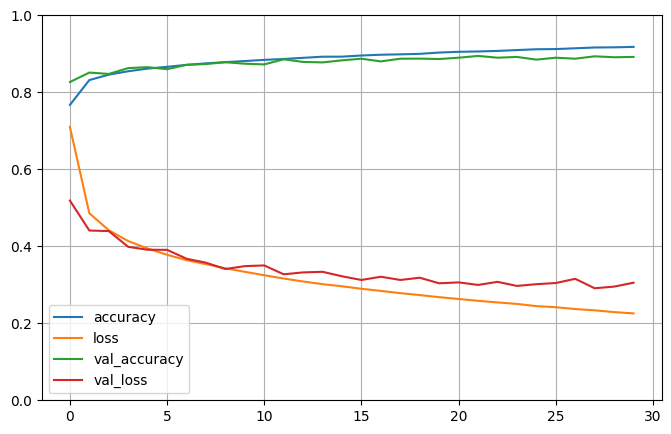

In [32]:
import pandas as pd
from matplotlib import pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [33]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8477 - loss: 69.0166


[69.01657104492188, 0.8476999998092651]

In [34]:
X_new = X_test[:3]
y_hat = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [35]:
y_hat

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [36]:
y_hat.round(2)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [37]:
y_pred = model.predict(X_new)
y_pred = y_pred.argmax(axis=-1)
np.array(class_names)[y_pred]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [38]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [39]:
housing = fetch_california_housing()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full)

In [40]:
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_valid_scaled = x_scaler.transform(X_valid)
X_test_scaled = x_scaler.transform(X_test)

In [41]:
X_train.shape

(11610, 8)

In [42]:
X_train.shape[1:]

(8,)

In [43]:
model_reg = keras.Sequential()
model_reg.add(keras.layers.Input(shape=X_train_scaled.shape[1:], name="input_layer"))
model_reg.add(keras.layers.Dense(units=100, activation="relu", name="layer_1"))
model_reg.add(keras.layers.Dense(units=50, activation="relu", name="layer_2"))
model_reg.add(keras.layers.Dense(units=1, activation=None, name="output_layer"))

In [44]:
model_reg.compile(loss="mse",optimizer="sgd",metrics=["mse"])

In [45]:
history = model_reg.fit(X_train_scaled,y_train, validation_data=[X_valid_scaled,y_valid],epochs=30)

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6742 - mse: 0.6742 - val_loss: 3.5029 - val_mse: 3.5029
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6074 - mse: 0.6074 - val_loss: 0.4378 - val_mse: 0.4378
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4316 - mse: 0.4316 - val_loss: 0.4147 - val_mse: 0.4147
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4046 - mse: 0.4046 - val_loss: 0.3936 - val_mse: 0.3936
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3716 - mse: 0.3716 - val_loss: 0.3771 - val_mse: 0.3771
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3590 - mse: 0.3590 - val_loss: 0.3713 - val_mse: 0.3713
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3508 - mse: 0.3508 - val_loss: 0.3648 - val_mse: 0.3648
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3443 - mse: 0.3443 - val_loss: 0.3787 - val_mse: 0.3787
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1000us/step -

In [46]:
y_hat = model_reg.predict(X_test_scaled)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 665us/step


In [47]:
y_hat

array([[1.5323939],
       [2.3334343],
       [2.3556342],
       ...,
       [3.3490367],
       [3.5884264],
       [2.8642125]], shape=(5160, 1), dtype=float32)

In [48]:
y_test

array([1.625, 1.823, 1.878, ..., 3.044, 3.553, 1.941], shape=(5160,))

In [49]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test,y_hat)

In [50]:
mse

0.39068365854933573

In [51]:
input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.Concatenate()([input_,hidden2])
output = keras.layers.Dense(1, activation=None)(concat)
model_deep = keras.Model(inputs=[input_], outputs=[output])

In [52]:
model_deep.compile(loss="mse", metrics=["mse"], optimizer="adam")

In [53]:
history = model_deep.fit(X_train_scaled,y_train,validation_data=[X_valid_scaled,y_valid],epochs=30)

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.2489 - mse: 1.2489 - val_loss: 0.5739 - val_mse: 0.5739
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4550 - mse: 0.4550 - val_loss: 0.4428 - val_mse: 0.4428
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4199 - mse: 0.4199 - val_loss: 0.4161 - val_mse: 0.4161
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4224 - mse: 0.4224 - val_loss: 0.4069 - val_mse: 0.4069
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3927 - mse: 0.3927 - val_loss: 0.3893 - val_mse: 0.3893
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3801 - mse: 0.3801 - val_loss: 0.3915 - val_mse: 0.3915
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4023 - mse: 0.4023 - val_loss: 0.3573 - val_mse: 0.3573
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3795 - mse: 0.3795 - val_loss: 0.3493 - val_mse: 0.3493
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

In [54]:
input_A = keras.layers.Input(shape=[5],name="wide_input")
input_B = keras.layers.Input(shape=[6],name="deep_input")
hidden1 = keras.layers.Dense(30,name="hidden_1")(input_B)
hidden2 = keras.layers.Dense(30,name="hidden_2")(hidden1)
concat = keras.layers.Concatenate()([input_A,hidden2])
output = keras.layers.Dense(1,name="output")(concat)

model_deep_2 = keras.Model(inputs=[input_A,input_B],outputs=[output])

In [55]:
model_deep_2.compile(loss="mse",optimizer="adam")

X_train_A, X_train_B = X_train[:, :5], X_train[:, 2:]
X_valid_A, X_valid_B = X_valid[:, :5], X_valid[:, 2:]

X_test_A, X_test_B = X_test[:, :5], X_test[:, 2:]
X_new_A, X_new_B = X_test_A[:3], X_test_B[:3]

In [56]:
history = model_deep_2.fit((X_train_A,X_train_B),y_train,epochs=32,validation_data=((X_valid_A,X_valid_B),y_valid))

Epoch 1/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7025.9399 - val_loss: 5.2136
Epoch 2/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.1961 - val_loss: 4.8625
Epoch 3/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.8501 - val_loss: 4.6385
Epoch 4/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.4691 - val_loss: 4.0178
Epoch 5/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.4104 - val_loss: 3.5181
Epoch 6/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.1551 - val_loss: 3.2417
Epoch 7/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.7868 - val_loss: 4.0853
Epoch 8/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.9610 - val_loss: 2.1396
Epoch 9/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 758.3836 - val_loss: 2504.3589
Epoch 10/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 39.9999 - val_loss: 1.7982
Epoch 11/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.8315 - val_loss: 1.5028
Epoch 12/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s

In [57]:
# output = keras.layers.Dense(1,name="output")(concat)
# aux_output = keras.layers.Dense(1,name="aux_output")(hidden2)
# model = keras.Model(inputs=[input_A,input_B],outputs[output,aux_output])
# model.compile(loss=["mse","mse"], loss_weights=[0.9,0.1], optimizer="sgd"]
# history = model.fit(
# [X_train_A,X_train_B], [y_train,y_train], epochs=20, validation_data=([X_valid_A,X_valid_B]),[y_valid,y_valid]))

#total_loss, main_loss, aux_loss = model.evaluate([X_test_A,X_test,B],[y_test,y_test])

#y_pred_main, y_pred_aux = model.predict([X_new_A,X_new_B])

##DOUBLE OUTPUT HERE

In [60]:
class WideAndDeepModel(keras.Model):
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs) ##handles standard arguments(eg.name)
        self.hidden1 = keras.layers.Dense(units,activation=activation)
        self.hidden2 = keras.layers.Dense(units,activation=activation)
        self.main_output = keras.layers.Dense(1)
        self.aux_output = keras.layers.Dense(1)
    
    def call(self, inputs):
        input_A, input_B = inputs
        hidden1 = self.hidden1(input_B)
        hidden2 = self.hidden2(hidden1)
        concat = keras.layers.concatenate([input_A,hidden2])
        main_output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return main_output, aux_output

model= WideAndDeepModel()

In [ ]:
model.save("saving_the_model.h5")
model = keras.models.load_model("saving_the_model.h5")

In [64]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("saving_the_best.h5",save_best_only=True)
early_stop_cb = keras.callbacks.EarlyStopping(patience=10,restore_best_weights=True)
history = model.fit(X,y,callbacks=[checkpoint_cb])
load_model = keras.models.load_models("saving_the_best.h5")

ValueError: You must call `compile()` before using the model.

In [65]:
class PrintValTrainRatioCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        print("\nval/train: {:.2f}".format(logs["val_loss"]/logs["loss"]))

In [66]:
import os 
root_logdir = os.path.join(os.curdir, "my_logs")

def get_run_logdir():
    import time
    run_id = time.strftime("run_%Y_%m_%d_%H,%M_%S")
    return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir()

In [71]:
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)
history = model_deep.fit(X_train,y_train,epochs=30,
                    validation_data=[X_valid,y_valid],
                    callbacks=[tensorboard_cb])

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 490.5356 - mse: 490.5356 - val_loss: 4.6527 - val_mse: 4.6527
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.0509 - mse: 5.0509 - val_loss: 2.3409 - val_mse: 2.3409
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.4953 - mse: 2.4953 - val_loss: 12.4859 - val_mse: 12.4859
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.8046 - mse: 1.8046 - val_loss: 1.0801 - val_mse: 1.0801
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.1320 - mse: 1.1320 - val_loss: 0.9191 - val_mse: 0.9191
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9508 - mse: 0.9508 - val_loss: 0.7811 - val_mse: 0.7811
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8764 - mse: 0.8764 - val_loss: 0.7781 - val_mse: 0.7781
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7865 - mse: 0.7865 - val_loss: 0.7412 - val_mse: 0.7412
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/ste

In [72]:
##launch tensorboard through jupyter lab

%load_ext tensorboard
%tensorboard --logdir ./my_logs

In [77]:
test_logdir = get_run_logdir()
writer = tf.summary.create_file_writer(test_logdir)
with writer.as_default():
    for step in range(1,1000 + 1):
        tf.summary.scalar("my_scalar", np.sin(step / 10), step=step)
        
        data = (np.random.randn(100) + 2) * step / 100
        tf.summary.histogram("my_hist", data, buckets=50, step=step)
        
        images = np.random.rand(2,32,32,3)
        tf.summary.image("my_images", images * step /1000, step=step)

        texts = ["The step is" + str(step), "Its square is" + str(step**2)]
        tf.summary.text("my_text", texts, step=step)

        sine_wave = tf.math.sin(tf.range(12000) / 48000 * 2 * np.pi * step)
        audio = tf.reshape(tf.cast(sine_wave, tf.float32), [1, -1, 1])
        tf.summary.audio("my_audio", audio, sample_rate=48000, step=step)

In [80]:
%tensorboard --logdir ./my_logs

Reusing TensorBoard on port 6006 (pid 10692), started 0:12:35 ago. (Use '!kill 10692' to kill it.)

In [85]:
def build_model(n_hidden=1,n_neurons=30, learning_rate=3e-3, input_shape=[8]):
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=input_shape))
    for layer in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons,activation="relu"))

    model.add(keras.layers.Dense(1))
    model.compile(loss="mse",optimizer="adam")
    return model

In [88]:
from scikeras.wrappers import KerasRegressor

keras_reg = KerasRegressor(build_model)

In [91]:
keras_reg.fit(X_train,y_train, epochs=100,
              validation_data=[X_valid,y_valid], callbacks=[keras.callbacks.EarlyStopping(patience=10)])
mse_test = keras_reg.score(X_test,y_test)
y_pred = keras_reg.predict(X_test)

Epoch 1/100


C:\Users\Berkay\Desktop\ML_projects\LSTM_sentiment\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 612.7155 - val_loss: 4.5091
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - loss: 6.9206 - val_loss: 3.4914
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step - loss: 4.6588 - val_loss: 2.3159
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - loss: 3.6776 - val_loss: 2.0071
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - loss: 2.5374 - val_loss: 1.5689
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - loss: 1.7821 - val_loss: 1.4876
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step - loss: 1.4100 - val_loss: 1.2209
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step - loss: 1.2469 - val_loss: 1.2027
Epoch 9/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step - loss: 1.0832 - val_loss: 1.0668
Epoch 10/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step - loss: 1.1668 - val_loss: 1.0346
Epoch 11/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - loss: 1.1881 - val_loss: 1.4008
Epoch 12/100
363/363 ━━━━━━━━━━

In [ ]:
# from scipy.stats import reciprocal
# from sklearn.model_selection import RandomizedSearchCV

# params = {
#     "n_hidden":[0,1,2,3],
#     "n_neurons": np.arange(1,100),
#     "learning_rate": reciprocal(3e-4, 3e-2)
# }

# rnd_search_cv = RandomizedSearchCV(keras_reg, params,n_iters=10,cv=3)
# rnd_search_cv.fit(X_train,y_train, epochs=100,
#               validation_data=[X_valid,y_valid], callbacks=[keras.callbacks.EarlyStopping(patience=10)])

In [93]:
## rnd_search_cv.best_params_
## rnd_search_cv.best_score_
## model = rnd_search_cv.best_estimator_.model